<a href="https://colab.research.google.com/github/Lorealejandrac/-Pipeline-de-Modelizaci-n-Predictiva/blob/main/Pipeline_ELT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Introducción del Proyecto**
# Predictive Modeling Pipeline

Este Notebook presenta un trabajo completo de modelización predictiva, que incluye la limpieza de datos y modelo de regresión.

El objetivo es demostrar la estructura de proceso de analisis de datos, mediantela preparación de un data origen tipo csv, hasta la preparación y evolución del modelo y sus interpretaciones.

# **2. Libraries**

In [ ]:
# Carga de paquetes necesarios

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Estadística
import scipy.stats as stats
from scipy.stats.mstats import winsorize

# Modelado
import patsy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import metrics

# Multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **3. Data Loading**

Es importante observar el dataset y entender el tipo de datos antes de modelar.

In [18]:
# Montar drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install missingno
!pip install feature_engine
!pip install pyarrow
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.3 MB/s eta 0:00:00


In [21]:
# Acceso a carpeta y carga del archivo de funciones
import sys
sys.path.append('/content/drive/MyDrive/UCM/Documentación minería de datos y model predictiva20260120')

# Importar funciones
from NuestrasFunciones import *


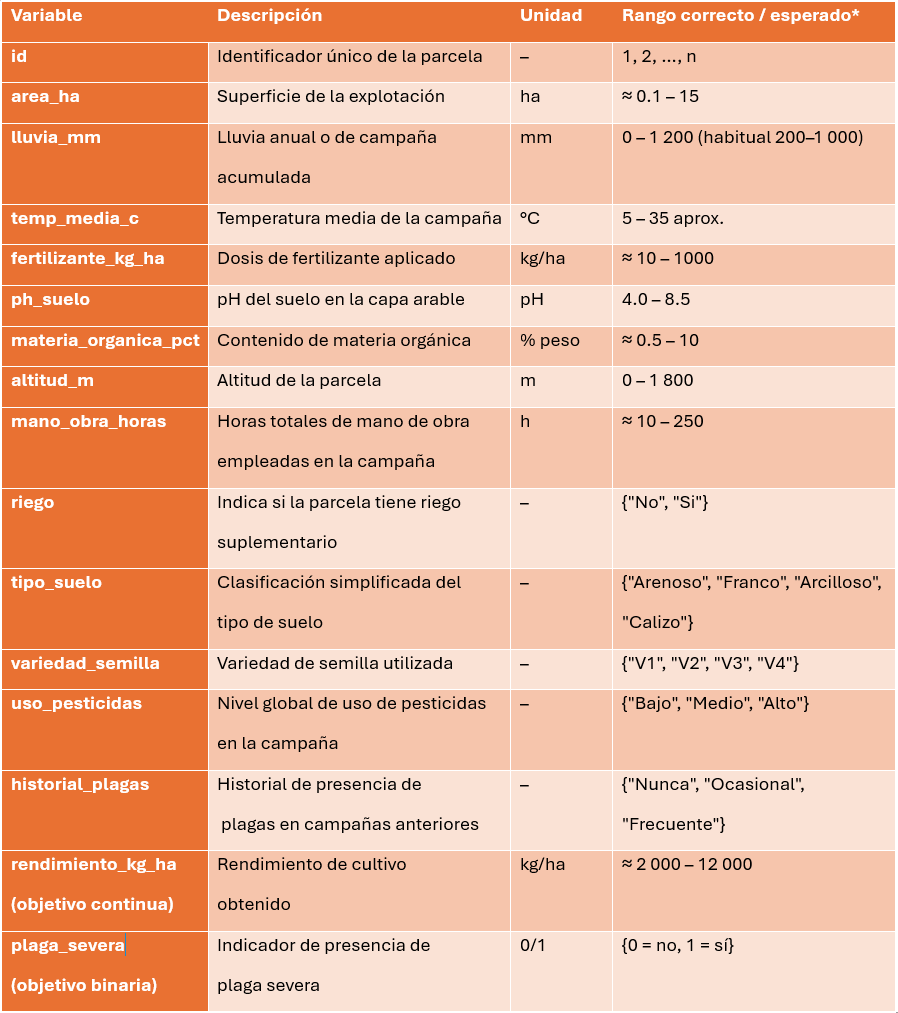

In [22]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/UCM/Documentación minería de datos y model predictiva20260120/Tarea Minería 25_26_Online/Tabla_Variables_Agri.png",width=600))

In [23]:
# Lectura datos agricultura
agricultura_original = pd.read_csv('/content/drive/MyDrive/UCM/Documentación minería de datos y model predictiva20260120/Tarea Minería 25_26_Online/Datos_agricultura_25.csv')
agricultura_original.head()

,Unnamed: 0,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente,6380.726608,1
3,3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


# **4. Data Cleaning and Preparation**

In [24]:
# Crear copia de trabajo
agricultura = agricultura_original.copy()

In [25]:
# Comprobación datos
# Información del dataset
agricultura.info()
agricultura.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            3600 non-null   int64  
 1   id                    3600 non-null   int64  
 2   area_ha               3600 non-null   float64
 3   lluvia_mm             3492 non-null   float64
 4   temp_media_c          3600 non-null   float64
 5   fertilizante_kg_ha    3600 non-null   float64
 6   ph_suelo              3564 non-null   float64
 7   materia_organica_pct  3528 non-null   float64
 8   altitud_m             3600 non-null   float64
 9   mano_obra_horas       3600 non-null   float64
 10  riego                 3600 non-null   object 
 11  tipo_suelo            3600 non-null   object 
 12  variedad_semilla      3600 non-null   object 
 13  uso_pesticidas        2880 non-null   object 
 14  historial_plagas      3600 non-null   object 
 15  rendimiento_kg_ha    

,Unnamed: 0,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,rendimiento_kg_ha,plaga_severa
count,3600.000000,3600.000000,3600.000000,3492.000000,3600.000000,3600.000000,3564.000000,3528.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,1799.500000,1800.500000,3.580980,616.805009,18.174277,150.944151,6.467852,2.991493,453.828165,120.104355,7112.238056,0.413889
std,1039.374812,1039.374812,2.085734,191.521172,4.574675,122.427301,0.854143,1.911530,251.185149,39.435212,635.761083,0.492597
min,0.000000,1.000000,0.160462,-50.000000,4.084211,10.631405,-1.000000,0.052297,0.000000,10.000000,3444.274993,0.000000
25%,899.750000,900.750000,2.091943,493.000881,15.427900,81.330456,6.009324,1.582046,269.097251,93.418539,6722.791706,0.000000
50%,1799.500000,1800.500000,3.165711,616.639586,18.056574,122.537424,6.492729,2.564343,449.859955,120.882717,7146.021777,0.000000
75%,2699.250000,2700.250000,4.652204,749.336374,20.773033,184.241773,6.953757,4.001123,627.425705,147.474745,7547.974406,1.000000
max,3599.000000,3600.000000,14.889630,1301.291583,60.000000,3230.906894,14.000000,18.875801,1329.738862,242.058152,9123.621299,1.000000


In [26]:
# Número de valores distintos (únicos) por variable
agricultura.nunique()

,0
Unnamed: 0,3600
id,3600
area_ha,3600
lluvia_mm,3483
temp_media_c,3591
fertilizante_kg_ha,3600
ph_suelo,3544
materia_organica_pct,3528
altitud_m,3451
mano_obra_horas,3593


In [27]:
# Se cuentan los valores por tipo de suelo
agricultura["tipo_suelo"].value_counts(dropna=False)

,count
tipo_suelo,
Franco,1307
Arcilloso,901
Arenoso,886
Calizo,367
Franco,139


In [28]:
 # Evaluamos porcentaje de nulos
(agricultura.isnull().sum() / len(agricultura)) * 100

,0
Unnamed: 0,0.0
id,0.0
area_ha,0.0
lluvia_mm,3.0
temp_media_c,0.0
fertilizante_kg_ha,0.0
ph_suelo,1.0
materia_organica_pct,2.0
altitud_m,0.0
mano_obra_horas,0.0


In [29]:
# Se quiere evaluar si los missings son aleatorios o siguen un patrón evidente.
# Un paso adicional para decidir si se ejecuta la imputación.

pd.crosstab(
    agricultura["uso_pesticidas"].isnull(),
    agricultura["plaga_severa"],
    normalize="index"
)

plaga_severa,0,1
uso_pesticidas,,
False,0.588542,0.411458
True,0.576389,0.423611


 **Comentarios de diagnóstico**:

La estructura general es de 3600 filas, 17 columnas, con


*   **float(6)**: variables numéricas continuas
*   **int64(3)**: Unmaned: 0, id, plaga_severa
*   **object(5)**: categóricas (riesgo, tipo_suelo, variedad_semilla, uso_pesticidas, historial_plagas)
*   **Columna sospechosa**: Unnamed: 0. Tiene pinta de ser un índice exportado.



In [30]:
# Cambios de tipos de variables
# De object a category
cols_cat = ["riego","tipo_suelo","variedad_semilla","uso_pesticidas","historial_plagas"]
agricultura[cols_cat] = agricultura[cols_cat].astype("category")
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0            3600 non-null   int64   
 1   id                    3600 non-null   int64   
 2   area_ha               3600 non-null   float64 
 3   lluvia_mm             3492 non-null   float64 
 4   temp_media_c          3600 non-null   float64 
 5   fertilizante_kg_ha    3600 non-null   float64 
 6   ph_suelo              3564 non-null   float64 
 7   materia_organica_pct  3528 non-null   float64 
 8   altitud_m             3600 non-null   float64 
 9   mano_obra_horas       3600 non-null   float64 
 10  riego                 3600 non-null   category
 11  tipo_suelo            3600 non-null   category
 12  variedad_semilla      3600 non-null   category
 13  uso_pesticidas        2880 non-null   category
 14  historial_plagas      3600 non-null   category
 15  rend

In [31]:
# Corrección de errores

#normalizamos espacios en tipo_suelo
agricultura["tipo_suelo"] = agricultura["tipo_suelo"].str.strip()
agricultura["tipo_suelo"].value_counts(dropna=False)

# Imputación de missings para porcentajes pequeños
cols_num = ["lluvia_mm", "ph_suelo", "materia_organica_pct"]

for col in cols_num:
    agricultura[col].fillna(agricultura[col].median(), inplace=True)

# Se crea nueva categoria "Desconocidos"
agricultura["uso_pesticidas"] = agricultura["uso_pesticidas"].cat.add_categories("Desconocido")
agricultura["uso_pesticidas"].fillna("Desconocido", inplace=True)

/tmp/ipykernel_454/1787644009.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agricultura[col].fillna(agricultura[col].median(), inplace=True)
/tmp/ipykernel_454/1787644009.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [32]:
# Evaluamos de nuevo el resultado
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0            3600 non-null   int64   
 1   id                    3600 non-null   int64   
 2   area_ha               3600 non-null   float64 
 3   lluvia_mm             3600 non-null   float64 
 4   temp_media_c          3600 non-null   float64 
 5   fertilizante_kg_ha    3600 non-null   float64 
 6   ph_suelo              3600 non-null   float64 
 7   materia_organica_pct  3600 non-null   float64 
 8   altitud_m             3600 non-null   float64 
 9   mano_obra_horas       3600 non-null   float64 
 10  riego                 3600 non-null   category
 11  tipo_suelo            3600 non-null   object  
 12  variedad_semilla      3600 non-null   category
 13  uso_pesticidas        3600 non-null   category
 14  historial_plagas      3600 non-null   category
 15  rend

In [33]:
# Se decide eliminar id y Unnamed: 0
agricultura = agricultura.drop(columns=["Unnamed: 0", "id"])

In [34]:
# Separar variables objetivo
# Crear input de predictores

# para regresión
y_reg = agricultura["rendimiento_kg_ha"]
X_reg = agricultura.drop(columns=["rendimiento_kg_ha"])

# para logística
y_log = agricultura["plaga_severa"]
X_log = agricultura.drop(columns=["plaga_severa"])

**Comentarios**:

**Justificación de acciones**:

Las variables numéricas con bajo porcentaje de valores ausentes (menor a 5%) fueron imputadas mediante la **mediana** para evitar distorsión por valores extremos.

En el caso de la variable categórica **uso_pesticidas**, con un **20% de datos faltantes**, se **creó una nueva categoría “Desconocido”** para preservar la información y evitar sesgos por imputación modal.

**La variable Unnamed: 0** corresponde a un **índice generado automáticamente durante la exportación del dataset**, por lo que no contiene información relevante para el análisis y **fue eliminada**.

**La variable id representa un identificador único por observación.** Al no aportar información predictiva y poder introducir ruido en los modelos, **se excluyó del conjunto de predictores.**

# **Incidencia outliers**

In [35]:
agricultura.describe()

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,rendimiento_kg_ha,plaga_severa
count,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,3.580980,616.800046,18.174277,150.944151,6.468101,2.982950,453.828165,120.104355,7112.238056,0.413889
std,2.085734,188.625670,4.574675,122.427301,0.849864,1.893258,251.185149,39.435212,635.761083,0.492597
min,0.160462,-50.000000,4.084211,10.631405,-1.000000,0.052297,0.000000,10.000000,3444.274993,0.000000
25%,2.091943,497.775363,15.427900,81.330456,6.016858,1.598746,269.097251,93.418539,6722.791706,0.000000
50%,3.165711,616.639586,18.056574,122.537424,6.492729,2.564343,449.859955,120.882717,7146.021777,0.000000
75%,4.652204,744.871943,20.773033,184.241773,6.949881,3.956841,627.425705,147.474745,7547.974406,1.000000
max,14.889630,1301.291583,60.000000,3230.906894,14.000000,18.875801,1329.738862,242.058152,9123.621299,1.000000


 ***Variables con valores fuera de rango***:  


*   ph_suelo: min y máx fuera de rango (posibles valores inválidos)
*   temp_media_c: max fuera de rango (posible registro fuera de escala)


*   fertilizante_kg_ha: max fuera de rango (posible outlier)


*   materia_organica_pct: max fuera de rango (posible registro fuera de escala)


*   lluvia_mm: max fuera de rango (posible outlier)

 ***Variables categóricas con más número de clasificaciones***:  


*   tipo_suelo: 5 y deberian haber 4.
Al verificar "tipo_suelo" se llega observa que una categoría tiene str distintos: Se deben normalizar los espacios.

 ***Porcentaje de nulos o missings***:


*   Nulos pequeños (1% - 3%): lluvia_mm, ph_suelo, materia_organica_pct. Como son bajos, probablemente se imputará, sin problema con su mediana
*   Caso especial: uso_pesticidas (20%): Se crearía una categoria "Desconocido". Si imputáramos, distorcionaría proporciones. Además, no se observó ningún patrón asociado fuerte al objetivo, no alteran medias y se distribuyen proporcionalmente.

# **Gestión efectiva de outliers**

In [36]:
# Evaluamos qué valores están fuera del rango establecido para pH de suelo agrícola.
# Observamos las características.

fuera_rango_ph = agricultura[
    (agricultura["ph_suelo"] < 4) |
    (agricultura["ph_suelo"] > 8.5)
]

fuera_rango_ph["ph_suelo"].describe()

,ph_suelo
count,18.000000
mean,2.722222
std,6.219566
min,-1.000000
25%,-1.000000
50%,0.000000
75%,0.000000
max,14.000000


In [37]:
# observamos el total de observaciones fuera de rango.
fuera_rango_ph.shape

(18, 15)

Se observa que hay **18 de 3600 observaciones fuera de rango**. De los cuales, son básicamente -1, 0, 14. Probablemente son códigos de error, valores mal registrados o indicadores no medidos. Porque **no existen pH 0 o negativos**. Además, el valor 14 aunque existe en escala química, en suelo agrícola es casi imposible. Asi que **no deben ser outliers**, son valores inválidos. **No se winsorizan, se convierten en NaN y se imputan por mediana.**

In [38]:
agricultura.loc[
    (agricultura["ph_suelo"] < 4) |
    (agricultura["ph_suelo"] > 8.5),
    "ph_suelo"
] = np.nan
agricultura["ph_suelo"].isnull().sum()

np.int64(18)

In [39]:
# Ahora observamos los valores fuera de rango para temperatura media en C.
# Observamos características.

fuera_rango_temp = agricultura[
    (agricultura["temp_media_c"] < 5) |
    (agricultura["temp_media_c"] > 35)
]

fuera_rango_temp["temp_media_c"].describe()

,temp_media_c
count,12.000000
mean,50.685957
std,21.752921
min,4.084211
25%,60.000000
50%,60.000000
75%,60.000000
max,60.000000


Se identificaron **12 observaciones fuera del rango agronómicamente plausible**. Los valores de 60°C fueron considerados **errores de registro y tratados como valores ausentes**. No se modificaron valores ligeramente inferiores a 5°C al considerarse físicamente plausibles.

In [40]:
# Se convierten en NaN, solo los valores fuera de rango mayores a 35, para no ser rígidos con los límites.
agricultura.loc[
    agricultura["temp_media_c"] > 35,
    "temp_media_c"
] = np.nan

In [41]:
# Se observan los valores fuera de rango de la variable fertilizante_kg_ha.
fuera_rango_fertilizante = agricultura[
    (agricultura["fertilizante_kg_ha"] < 10) |
    (agricultura["fertilizante_kg_ha"] > 1000)
]

fuera_rango_fertilizante["fertilizante_kg_ha"].describe()

,fertilizante_kg_ha
count,6.000000
mean,1596.613970
std,819.566153
min,1074.349149
25%,1155.422173
50%,1296.074542
75%,1504.324119
max,3230.906894


In [42]:
# Se convierten en NaN, valores por encima de 1000. Aunque sean valores brutalmente posibles,
# en agricultura real, 3000 kg/ha de fertilizante es muy poco probable.
agricultura.loc[
    agricultura["fertilizante_kg_ha"] > 1000,
    "fertilizante_kg_ha"
] = np.nan

Se detectaron **6 valores por encima del límite técnico esperado (1000 kg/ha)**. Dado su bajo porcentaje (0.17%) y la improbabilidad agronómica de dichos valores, **fueron tratados como registros erróneos y convertidos en valores ausentes.**

In [43]:
# Se observan los valores fuera de rango de la variable materia_organica_pct.
fuera_rango_materia_organica = agricultura[
    (agricultura["materia_organica_pct"] > 10)
]

fuera_rango_materia_organica["materia_organica_pct"].describe()

,materia_organica_pct
count,22.000000
mean,11.667069
std,1.978196
min,10.002270
25%,10.402345
50%,11.200393
75%,12.361515
max,18.875801


Como materia_organica_pct **tiene 22 casos (0.6%) con valores hasta de 18.8%**, debemos decidir si convertir en NaN o Winsorizar. Ya que **son observaciones extremadamente raras pero posibles**, es un suelo "casi orgánico puro". Sin embargo, es incoherente con el resto del dataset, **es 6 veces más alto**. Parece error de digitacion o escala mal registrada.
Se graficará su distribución para decidir con mayores pruebas.

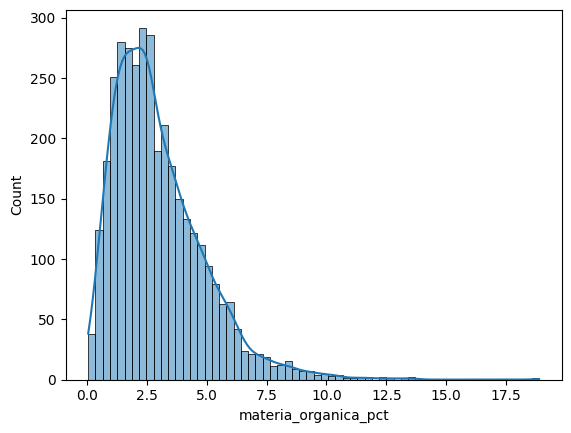

In [44]:
# Se grafica su distribución para comprobar que son totalmente aislados en la cola,
# outliers extremos.

sns.histplot(agricultura["materia_organica_pct"], kde=True)
plt.show()

**Se decide Winsorizar materia_organica_pct**

In [45]:
# Se evalúan los percentiles, para ver a donde se Winsorizan.

agricultura["materia_organica_pct"].quantile([0.95, 0.97, 0.99])

,materia_organica_pct
0.95,6.388768
0.97,7.341822
0.99,9.153255


In [46]:
# Se winsorizarán al percentil p99. Así, mantenemos el orden, reducimos influencia extrema,
# no eliminamos datos, no generamos MAS NaN.
p99 = agricultura["materia_organica_pct"].quantile(0.99)

agricultura["materia_organica_pct"] = np.where(
    agricultura["materia_organica_pct"] > p99,
    p99,
    agricultura["materia_organica_pct"]
)

In [47]:
# Se observan los valores fuera de rango de la variable lluvia_mm.
fuera_rango_materia_lluvia = agricultura[
    (agricultura["lluvia_mm"] > 1200)
]

fuera_rango_materia_lluvia["lluvia_mm"].describe()

,lluvia_mm
count,2.000000
mean,1273.707012
std,39.010473
min,1246.122442
25%,1259.914727
50%,1273.707012
75%,1287.499298
max,1301.291583


En este caso, **se decide no realizar ninguna imputación ni winsorización**. Son dos observaciones solamente, es físicamente posible, en muchas regiones agrícolas **1300 mm anuales es viable**. No es error evidente. **Lo dejamos**

**Justificación outliers**:



*   Los valores claramente imposibles o resultado de errores de registro (pH negativo, temperatura media de 60 °C, fertilización extremadamente elevada) fueron tratados como datos inválidos y convertidos en valores ausentes para su posterior imputación.

*  En el caso de variables con valores extremos pero físicamente plausibles (como materia orgánica), se aplicó winsorización al percentil superior para reducir la influencia de observaciones extremas sin eliminar información.

*   Los valores elevados de precipitación, al considerarse físicamente posibles, se mantuvieron sin modificación.

# **Incidencia de missings**

In [48]:
# Primero veamos cuáles tienen NaN ahora

agricultura.isnull().sum()

,0
area_ha,0
lluvia_mm,0
temp_media_c,10
fertilizante_kg_ha,6
ph_suelo,18
materia_organica_pct,0
altitud_m,0
mano_obra_horas,0
riego,0
tipo_suelo,0


In [49]:
# Luego imputamos solo las numéricas con NaN usando mediana:
cols_num = agricultura.select_dtypes(include=["float64"]).columns

for col in cols_num:
    agricultura[col].fillna(agricultura[col].median(), inplace=True)

/tmp/ipykernel_454/4053304562.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agricultura[col].fillna(agricultura[col].median(), inplace=True)


**Justificación missings**:

Los valores fuera de rango considerados físicamente imposibles o inconsistentes fueron tratados como errores de registro y convertidos en valores ausentes, con el fin de aplicar posteriormente una imputación adecuada y evitar sesgos en el modelado.

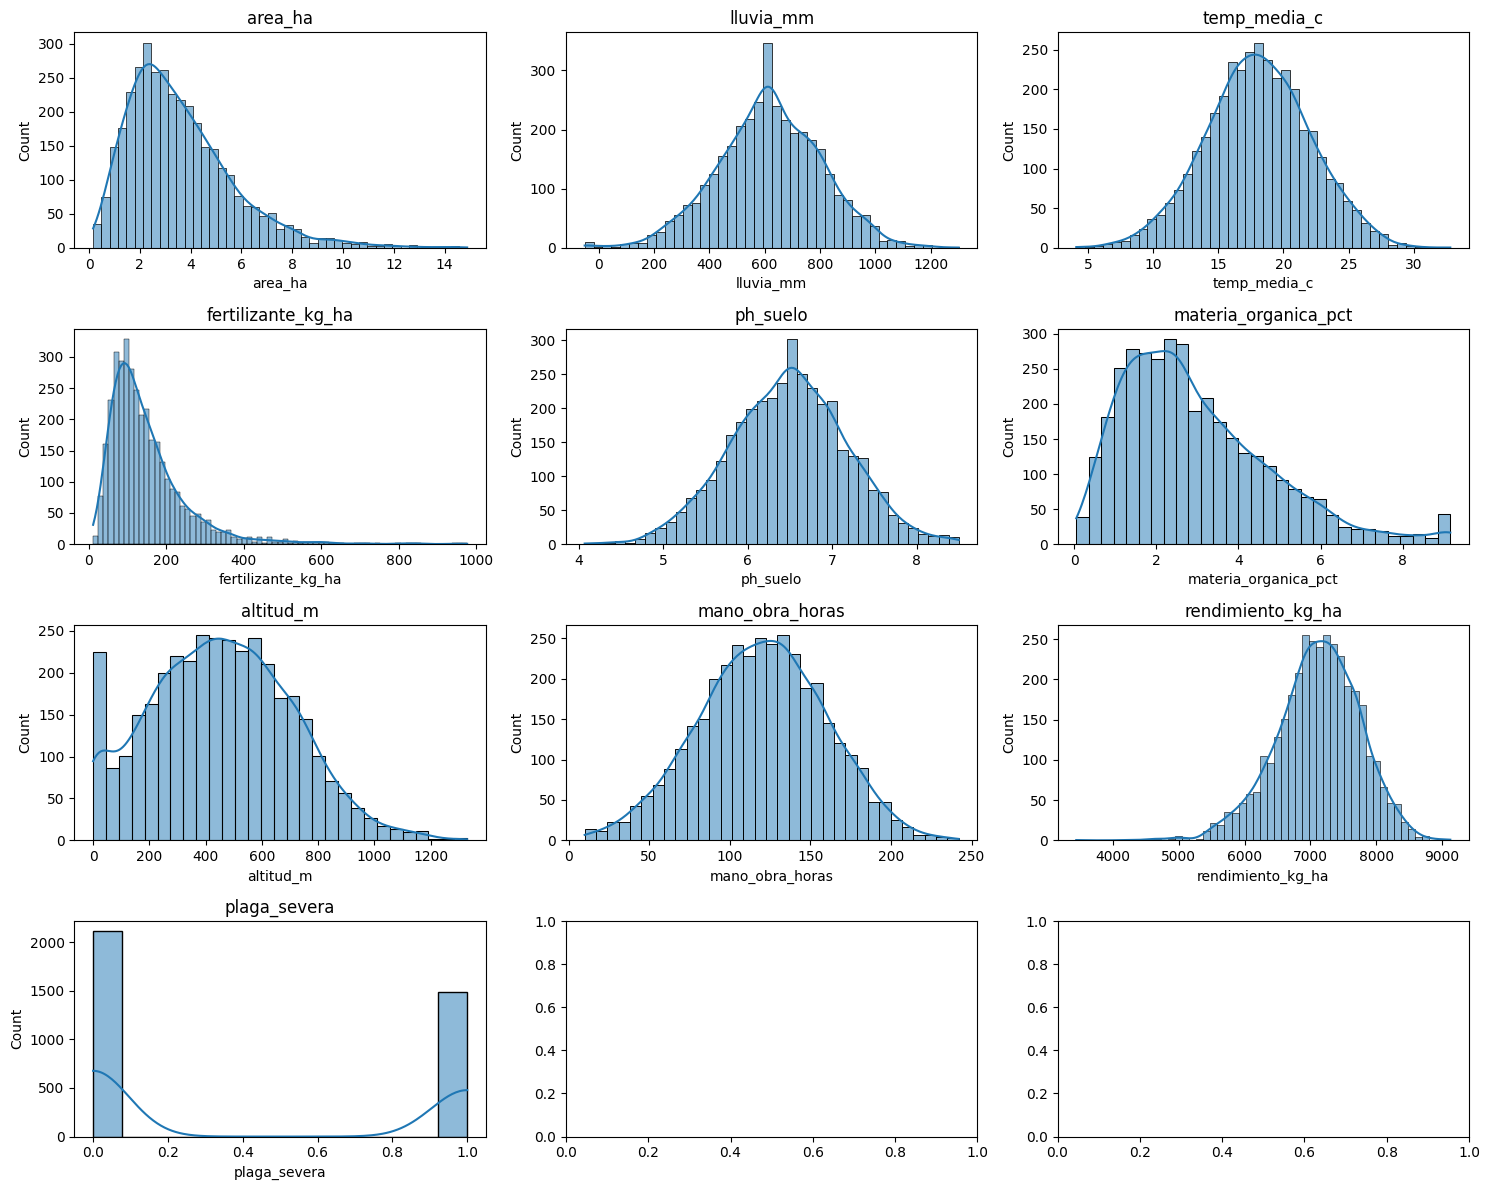

In [50]:
# Distribuciones de las variables corregidas

import matplotlib.pyplot as plt
import seaborn as sns
# Obtenemos las numéricas.
cols_num = agricultura.select_dtypes(include=["float64", "int64"]).columns

#graficamos todo en un subplot
n_cols = 3
n_rows = int(len(cols_num)/n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.histplot(agricultura[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


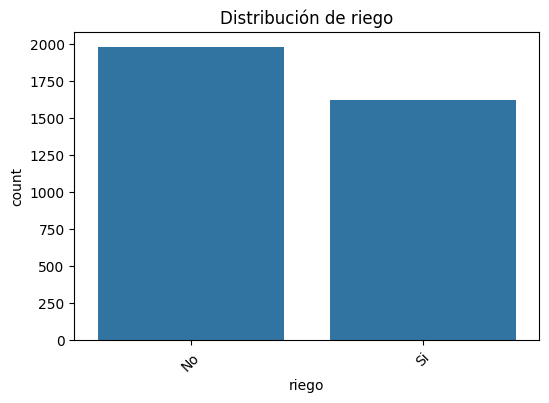

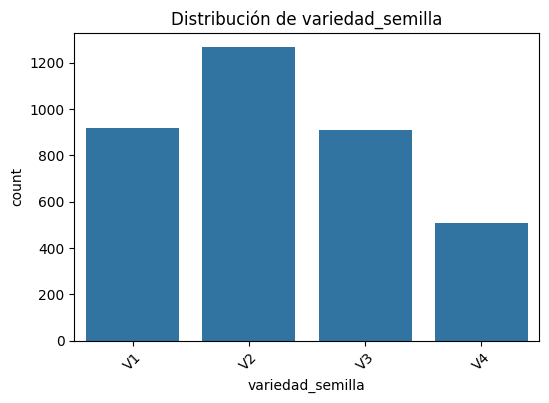

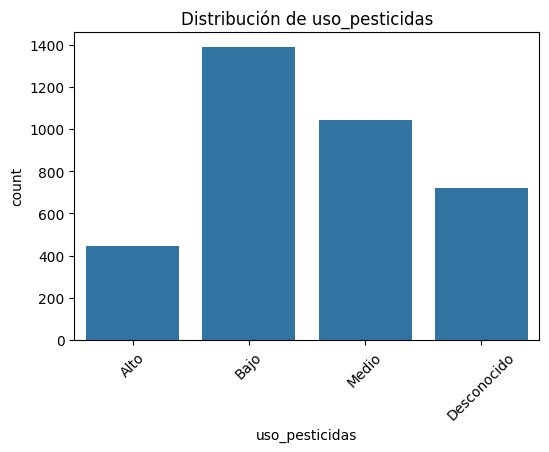

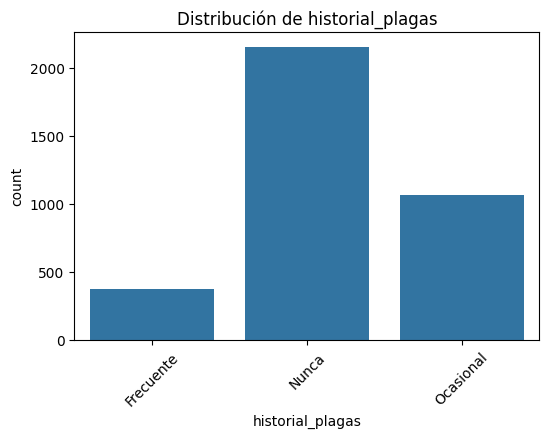

In [51]:
# variables categóricas
cols_cat = agricultura.select_dtypes(include=["category"]).columns
for col in cols_cat:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=agricultura)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()

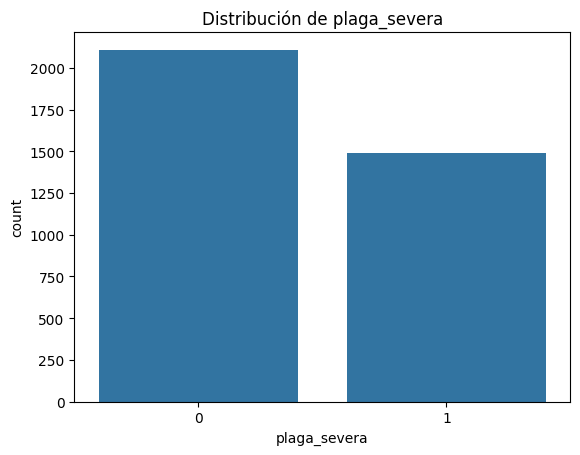

In [52]:
# Variable binaria objetivo
sns.countplot(x="plaga_severa", data=agricultura)
plt.title("Distribución de plaga_severa")
plt.show()

**Comentarios de proceso**

**Desiciones:**


*   pH: valores inválidos, convertidos en NaN
*   temperatura: 60ºC, NaN. Claramente errado


*   Fertilizante: 1000, NaN. Valores extremos improbables.
*   Materia orgánica: Winsorizada al percentil 99. Valor extremos plausible.


*   lluvia: Se mantiene, valor físico alto pero posible.


*   Posteriormente se procede a convertir los missing nuevos en la mediana de cada distribución.

# **Datos depurados**

In [53]:
agricultura.head()

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,2.335113,616.639586,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,Desconocido,Frecuente,6380.726608,1
3,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


In [54]:
agricultura.to_csv('/content/drive/MyDrive/UCM/Documentación minería de datos y model predictiva20260120/Tarea Minería 25_26_Online/agricultura_limpio.cvs', index=False)

 # Análisis de cambio
 Tras el proceso de depuración se realizaron las siguientes modificaciones:


*   Se eliminaron variables estructurales sin valor predictivo (Unnamed: 0, id)
*   Se corrigieron valores fuera de rango considerados errores de registro, transformándolos en valores ausentes.


*   Se aplicó winsorización en la variable materia_organica_pct para reducir la influencia de valores extremos plausibles.
*   Se imputaron los valores ausentes mediante la mediana en variables numéricas y mediante la creación de una categoría adicional en variables categóricas.

El número total de observaciones se mantuvo constante (3600 registros), preservando la estructura muestral. Tras el tratamiento, el dataset no presenta valores faltantes ni registros físicamente inconsistentes, mejorando su coherencia y robustez para el modelado posterior.

In [55]:
# Se crea un dataframe con las variables modificadas para comparar visualmente.

cols_cambios = [
    "ph_suelo",
    "temp_media_c",
    "fertilizante_kg_ha",
    "materia_organica_pct",
    "lluvia_mm"
]

comparacion = pd.DataFrame({
    "Media_Antes": agricultura_original[cols_cambios].mean(),
    "Media_Despues": agricultura[cols_cambios].mean(),
    "Max_Antes": agricultura_original[cols_cambios].max(),
    "Max_Despues": agricultura[cols_cambios].max(),
    "Min_Antes": agricultura_original[cols_cambios].min(),
    "Min_Despues": agricultura[cols_cambios].min(),
})

comparacion


,Media_Antes,Media_Despues,Max_Antes,Max_Despues,Min_Antes,Min_Despues
ph_suelo,6.467852,6.486954,14.000000,8.500000,-1.000000,4.066092
temp_media_c,18.174277,18.057732,60.000000,32.811904,4.084211,4.084211
fertilizante_kg_ha,150.944151,148.487085,3230.906894,976.852564,10.631405,10.631405
materia_organica_pct,2.991493,2.966121,18.875801,9.153255,0.052297,0.052297
lluvia_mm,616.805009,616.800046,1301.291583,1301.291583,-50.000000,-50.000000


**Observaciones**:


*   pH: Min_antes = -1, min_ahora >= 4
*   temp_media_c: max_antes = 60, max_ahora <= 35.


*   fertilizante: max_antes ≈  3230, max_ahora <= 1000
*   materia orgánica: max_antes ≈ 18.8, max_ahora ≈ percentil 99.


*   lluvia sin cambios


*   uso_pesticidas: sin missing, con clasificación "Desconocido".
*   observaciones completas 3600, en cada variable.



*   ya no se ve una columna id, ni Unnamed:0

# **5. Regression Modeling**

Creamos variables de control, totalmente aleatorias, que funcionan como línea base de asociación espuria.

Eso garantiza:

Independencia total respecto a la respuesta.

Ninguna estructura interna.

Ninguna correlación real.

In [56]:
# Generar aleatorios
import numpy as np

np.random.seed(42)
agricultura["aleatorio1"] = np.random.uniform(0, 1, size=agricultura.shape[0])
agricultura["aleatorio2"] = np.random.uniform(0, 1, size=agricultura.shape[0])

In [57]:
# Primero aseguramos que todas las categorias esten en tipo category
for col in agricultura.select_dtypes(include="object").columns:
    agricultura[col] = agricultura[col].astype("category")

# Ranking V de Cramer vs. obj continua

varObjCon = agricultura["rendimiento_kg_ha"]
inputPred = agricultura.drop(columns=["rendimiento_kg_ha"])

tablaCramer = pd.DataFrame(
    inputPred.apply(lambda x: cramers_v(x, varObjCon)),
    columns=["V_Cramer"]
).sort_values("V_Cramer", ascending=False)

In [58]:
tablaCramer.head(10)

,V_Cramer
lluvia_mm,0.500970
plaga_severa,0.181670
riego,0.163761
temp_media_c,0.083123
tipo_suelo,0.080673
fertilizante_kg_ha,0.078681
materia_organica_pct,0.062610
ph_suelo,0.053125
variedad_semilla,0.047645
area_ha,0.044696


/tmp/ipykernel_454/511564028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


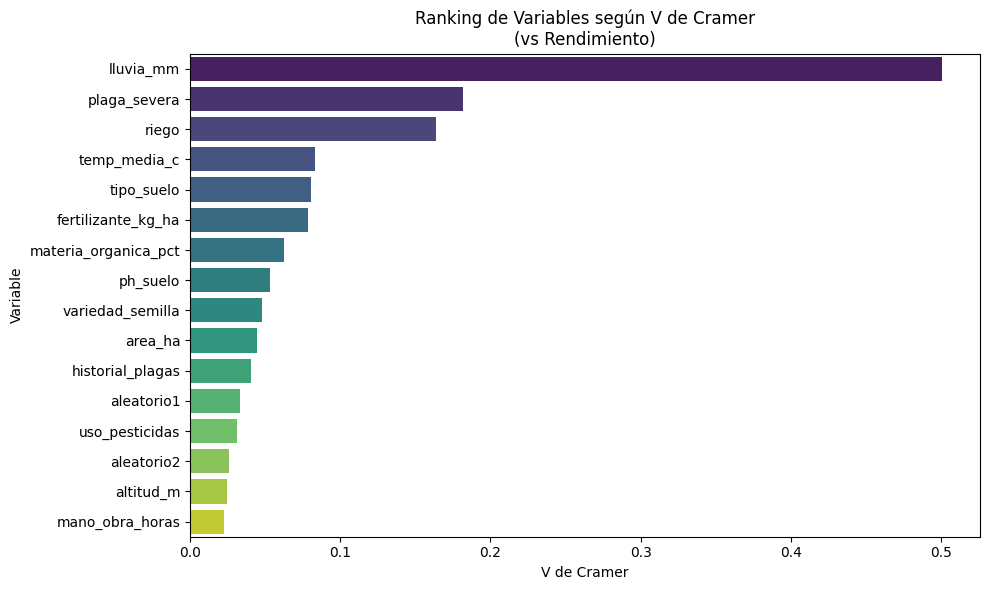

In [59]:
# Primero reseteamos índice para graficar mejor
ranking_plot = tablaCramer.reset_index()
ranking_plot.columns = ["Variable", "V_Cramer"]


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=ranking_plot,
    x="V_Cramer",
    y="Variable",
    palette="viridis"
)

plt.title("Ranking de Variables según V de Cramer\n(vs Rendimiento)")
plt.xlabel("V de Cramer")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()


El ranking de variables según la V de Cramer muestra que la precipitación (lluvia_mm) presenta la asociación más fuerte con el rendimiento, lo cual resulta coherente desde un punto de vista agronómico.

Variables como la presencia de plaga severa (plaga_severa) y el riego (riego) también evidencian una relación moderada con el rendimiento, indicando su potencial relevancia en el modelo predictivo.

El resto de variables presentan asociaciones débiles, aunque superiores a las variables de control aleatorias generadas. Esto sugiere que, aunque su contribución individual sea limitada, podrían aportar información en un modelo multivariante.

Las variables aleatorias (aleatorio1, aleatorio2) muestran valores de V cercanos a cero, lo que confirma la consistencia del método de evaluación y la ausencia de asociaciones espurias significativas.

# Fórmula modelo completo

In [60]:
form = ols_formula(
    agricultura,
    'rendimiento_kg_ha',
    'plaga_severa'
)
form

'rendimiento_kg_ha ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas + aleatorio1 + aleatorio2'

# Ajuste modelo completo

# Summary modelo completo

In [61]:
import statsmodels.formula.api as smf

modelo = smf.ols(formula=form, data=agricultura).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     837.5
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:17:08   Log-Likelihood:                -25075.
No. Observations:                3600   AIC:                         5.020e+04
Df Residuals:                    3577   BIC:                         5.034e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      4330.6701     55.879     77.501      0.000    4221.113    4440.228
riego[T.Si]                     225.8007      8.633     26.157      0.000     208.876     242.726
tipo_suelo[T.Arenoso]            -5.2286     12.176     -0.429      0.668     -29.100      18.643
tipo_suelo[T.Calizo]             13.6592     15.964      0.856      0.392     -17.640      44.958
tipo_suelo[T.Franco]            159.4623     10.938     14.578      0.000     138.016     180.908
variedad_semilla[T.V2]           16.5423     11.186      1.479      0.139      -5.390      38.474
variedad_semilla[T.V3]            5.9223     12.055      0.491      0.623     -17.713      29.558
variedad_semilla[T.V4]          132.4719     14.262      9.288      0.000     104.509     160.435
uso_pesticidas[T.Bajo]           10.3226     14.007      0.737      0.461     -17.140      37.785
uso_pesticidas[T.Medio]          21.3997     14.575      1.468      0.142      -7.176      49.975
uso_pesticidas[T.Desconocido]    -0.8245     15.506     -0.053      0.958     -31.226      29.577
historial_plagas[T.Nunca]       -23.9050     14.417     -1.658      0.097     -52.172       4.362
historial_plagas[T.Ocasional]   -13.4863     15.467     -0.872      0.383     -43.812      16.840
area_ha                           0.1156      2.062      0.056      0.955      -3.927       4.158
lluvia_mm                         2.8266      0.023    124.158      0.000       2.782       2.871
temp_media_c                     28.5646      1.072     26.637      0.000      26.462      30.667
fertilizante_kg_ha                1.1054      0.042     26.455      0.000       1.023       1.187
ph_suelo                          4.6342      6.271      0.739      0.460      -7.661      16.930
materia_organica_pct             43.1039      2.359     18.276      0.000      38.480      47.728
altitud_m                         0.0006      0.017      0.033      0.973      -0.033       0.034
mano_obra_horas                   0.2056      0.109      1.887      0.059      -0.008       0.419
aleatorio1                      -22.9336     14.799     -1.550      0.121     -51.950       6.083
aleatorio2                        5.6059     14.902      0.376      0.707     -23.612      34.824
==============================================================================
Omnibus:                     1299.310   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34975.582
Skew:                           1.128   Prob(JB):                         0.00
Kurtosis:                      18.102   Cond. No.                     1.08e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix

- R^2 = 0.837 y R^2 ajustado = 0.836. Interpretación: El modelo explica aproximadamente el **83.7%** de la variabilidad del rendimiento agrícola a partir del conjunto de predictores incluidos.
- H_0: Todos los coeficientes (excepto intercepto) = 0.
  H_1: Al menos uno es distinto de 0.
  F_statistic = 837.5. Prob(F-statist) =0.00.
  Interpretación: Se rechaza H_0 con un nivel de significación del 5%. El modelo en su conjunto es estadísticamente significtivo.
- El modelo tiene: Df Model = 22. Significa que son 22 efectos estimados.
Significativos claramente:


1.   riego[T.Si]
2.   tipo_suelo[T.Franco]
3.   variedad_semilla[T.V4]
4.   lluvia_mm
5.   temp_media_c
6.   fertilizante_kg_ha
7.   materia_organica_pct

  A simple vista hay 7 efectos claramente significativos.
Las variables aleatorias no son Significativas -> por tanto, el control funcionó.
- Durbin Watson = 1.994. No hay autocorrelación de residuos
Jarque-Bera p=0.00 se rechaza normalidad estricta de residuos.
Skew = 1.128: Asimetría positiva.
Kurtosis = 18.1, colas pesadas.
Por lo que hay algunos residuos extremos.
Cond. No = 1.08e+04, es importante porque puede indicar multicolinealidad.
**En conclusión:**El análisis residual muestra independencia de errores (Durbin Watson ≈ 2). Sin embargo, los tests de normalidad indican desviaciones respecto a la normalidad, posiblemente asociadas a colas pesadas. No obstante, dado el tamaño muestral elevado, estas desviaciones no comprometen la validez global del modelo.

# Selección automática Lasso

In [62]:
# Definimos X e Y y quitamos las variables que no van en la selección.
# objetivo: rendimiento_kg_ha.
# controles: aleatorio1, aleatorio2
# plaga_severa, se quitó antes por posible correlación con la objetivo.

y = agricultura["rendimiento_kg_ha"]

X = agricultura.drop(columns=["rendimiento_kg_ha", "plaga_severa", "aleatorio1", "aleatorio2"], errors="ignore")

In [63]:
# Pasar a dummies las variables category.

imput_dummy = pd.get_dummies(X, drop_first=True)
imput_dummy.shape, imput_dummy.head()

((3600, 20),
     area_ha   lluvia_mm  temp_media_c  fertilizante_kg_ha  ph_suelo  \
 0  1.639907  418.912109     12.947372           80.112469  6.378618   
 1  3.181230  829.883681     13.273468          120.907585  6.510040   
 2  2.335113  616.639586     15.318376          116.182533  6.338459   
 3  3.380414  596.452294     21.758124          259.092031  7.016593   
 4  2.119452  468.527190     17.286543          116.321076  5.538014   
 
    materia_organica_pct   altitud_m  mano_obra_horas  riego_Si  \
 0              0.961564  564.350321       117.657884      True   
 1              5.700165  848.351457       118.783270      True   
 2              1.862246  471.860055       158.016439     False   
 3              7.405093  792.009663        99.675733     False   
 4              0.371970  359.044071        95.332274      True   
 
    tipo_suelo_Arenoso  tipo_suelo_Calizo  tipo_suelo_Franco  \
 0               False              False               True   
 1               Fals

In [64]:
# Ajustar LassoLarsIC(BIC)

from sklearn import linear_model

reg = linear_model.LassoLarsIC(criterion='bic')
reg.fit(imput_dummy, y)

reg.coef_

array([0.00000000e+00, 2.82721936e+00, 2.84694145e+01, 1.10859783e+00,
       0.00000000e+00, 4.21350216e+01, 8.28464968e-04, 1.91812678e-01,
       2.11977556e+02, 0.00000000e+00, 0.00000000e+00, 1.45180314e+02,
       0.00000000e+00, 0.00000000e+00, 9.56138796e+01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [65]:
# Rescatamos variables con coeficiente distinto de 0

selected_cols = imput_dummy.columns[(reg.coef_ != 0).ravel().tolist()]
selected_cols


Index(['lluvia_mm', 'temp_media_c', 'fertilizante_kg_ha',
       'materia_organica_pct', 'altitud_m', 'mano_obra_horas', 'riego_Si',
       'tipo_suelo_Franco', 'variedad_semilla_V4'],
      dtype='object')

In [66]:
# Se evalúa cada una con su coeficiente.

coef_sel = pd.Series(reg.coef_, index=imput_dummy.columns)
coef_sel = coef_sel[coef_sel != 0].sort_values(key=np.abs, ascending=False)
coef_sel

,0
riego_Si,211.977556
tipo_suelo_Franco,145.180314
variedad_semilla_V4,95.613880
materia_organica_pct,42.135022
temp_media_c,28.469415
lluvia_mm,2.827219
fertilizante_kg_ha,1.108598
mano_obra_horas,0.191813
altitud_m,0.000828


In [67]:
# Detectar qué categóricas fueron seleccionadas.

cat_vars = ["riego", "tipo_suelo", "variedad_semilla", "uso_pesticidas", "historial_plagas"]

cats_in_model = []
for c in cat_vars:
    if any(col.startswith(c + "_") for col in selected_cols):
        cats_in_model.append(c)

cats_in_model

['riego', 'tipo_suelo', 'variedad_semilla']

In [68]:
# Detectamos las numéricas seleccionadas

num_vars = [c for c in X.columns if c not in cat_vars]
nums_in_model = [c for c in num_vars if c in selected_cols]

nums_in_model

['lluvia_mm',
 'temp_media_c',
 'fertilizante_kg_ha',
 'materia_organica_pct',
 'altitud_m',
 'mano_obra_horas']

In [69]:
#Armamos la fórmula final para OLS

import statsmodels.formula.api as smf

rhs = []
rhs += nums_in_model
rhs += [f"C({c})" for c in cats_in_model]

form_lasso = "rendimiento_kg_ha ~ " + " + ".join(rhs)
form_lasso

'rendimiento_kg_ha ~ lluvia_mm + temp_media_c + fertilizante_kg_ha + materia_organica_pct + altitud_m + mano_obra_horas + C(riego) + C(tipo_suelo) + C(variedad_semilla)'

In [70]:
# Ajustar OLS final y sacar métricas

modelo_lasso = smf.ols(formula=form_lasso, data=agricultura).fit()

# Summary modelo Lasso

In [71]:
print(modelo_lasso.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     1416.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:17:29   Log-Likelihood:                -25080.
No. Observations:                3600   AIC:                         5.019e+04
Df Residuals:                    3586   BIC:                         5.028e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [72]:
# a)
modelo_lasso.rsquared, modelo_lasso.rsquared_adj

(np.float64(0.8369599424981329), np.float64(0.8363688881904017))

In [73]:
# b)
n_efectos = len(modelo_lasso.params) - 1
n_signif = (modelo_lasso.pvalues.drop("Intercept") < 0.05).sum()

n_efectos, n_signif

(13, np.int64(7))

- El modelo reducido mediante Lasso presenta un **R^2 de 0.837**, prácticamente idéntico al modelo completo. Esto indica que la eliminación automática de variables en este caso no ha supuesto una pérdida relevante de capacidad explicativa. El modelo Lasso logra mantener el mismo nivel de ajuste con menor complejidas estructural **(De 22 a 13)**. **Lo que nos da un modelo mas parsimonioso sin sacrificar poder explicativo**
- **Son 13 efectos estimados** (sin contar la constante). **Y claramente significativos 7 efectos al nivel alpha = 0.05**. Esto indica que aproximadamente la mitad de los efectos retenidos por Lasso presentan evidencia estadística sólida de asociación con el rendimiento. Además, eliminó variables irrelevantes del modelo completo manteniendo aquellas con mayor impacto estructural.

-

**1.   Variable continua: lluvia_mm, coeficiente beta: 2.828.**

Manteniendo constantes las demás variables, **un incremento de un milímetro en la precipitación (lluvia)**, se asocia con un **aumento promedio de aproximadamente 2.83 kg/ha en el rendimiento**

**2.   Variable categórica: riego[T.Si], coeficiente beta: 226.15.**

Las parcelas **con riego** presentan, en promedio, un **rendimiento superior en aproximadamente 226 kg/h** respecto a las parcelas sin riego (categoría de referencia), manteniendo constante el resto de variables del modelo.

# Generar transformaciones

In [74]:
# Separamos la variable dependiente como siempre, y excluimos aleatorios y plaga_severa.

y = agricultura["rendimiento_kg_ha"]

X_base = agricultura.drop(columns=["rendimiento_kg_ha", "plaga_severa", "aleatorio1", "aleatorio2"], errors="ignore")

In [75]:
# Detectamos variables continuas (numéricas) a transformar

num_cols = X_base.select_dtypes(include=["float64", "int64"]).columns
num_cols

Index(['area_ha', 'lluvia_mm', 'temp_media_c', 'fertilizante_kg_ha',
       'ph_suelo', 'materia_organica_pct', 'altitud_m', 'mano_obra_horas'],
      dtype='object')

In [76]:
# Como estamos trabajando con una variable continua como dependiente, usamos tipo= "cor"

# Crear dataframe con las mejores transformaciones
X_transf = pd.DataFrame(index=agricultura.index)

for col in num_cols:
    X_transf[mejorTransf(agricultura[col], y, name=True, tipo="cor")] = mejorTransf(agricultura[col], y, tipo="cor")

X_transf.head()

,area_ha_cuarta,lluvia_mm_ident,temp_media_c_sqr,fertilizante_kg_ha_raiz4,ph_suelo_exp,materia_organica_pct_ident,altitud_m_cuarta,mano_obra_horas_sqr
0,0.253423,2.486385,4.895214,0.906791,29.290606,0.499630,25.499865,7.455483
1,4.403470,4.665456,5.262037,1.017782,35.487912,3.102908,130.202746,7.612161
2,1.182852,3.534784,7.864439,1.006701,27.622170,0.994444,12.462661,14.092736
3,5.684810,3.427746,19.464366,1.246933,74.362478,4.039556,98.910519,5.172975
4,0.778969,2.749457,10.861326,1.007031,8.581985,0.175721,4.178092,4.684023


# Unir al input de predictores

In [77]:
cat_cols = X_base.select_dtypes(include=["category"]).columns
X_cat = X_base[cat_cols].copy()

X_full = pd.concat([X_transf, X_cat], axis=1)
X_full.shape
X_full.head()

,area_ha_cuarta,lluvia_mm_ident,temp_media_c_sqr,fertilizante_kg_ha_raiz4,ph_suelo_exp,materia_organica_pct_ident,altitud_m_cuarta,mano_obra_horas_sqr,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
0,0.253423,2.486385,4.895214,0.906791,29.290606,0.499630,25.499865,7.455483,Si,Franco,V1,Alto,Nunca
1,4.403470,4.665456,5.262037,1.017782,35.487912,3.102908,130.202746,7.612161,Si,Franco,V2,Medio,Nunca
2,1.182852,3.534784,7.864439,1.006701,27.622170,0.994444,12.462661,14.092736,No,Franco,V1,Desconocido,Frecuente
3,5.684810,3.427746,19.464366,1.246933,74.362478,4.039556,98.910519,5.172975,No,Arcilloso,V2,Medio,Ocasional
4,0.778969,2.749457,10.861326,1.007031,8.581985,0.175721,4.178092,4.684023,Si,Arenoso,V1,Alto,Frecuente


# Aplicar SFS

In [78]:
# Se pasan a dummies las categoricas para hacer SFS

X_full_dummy = pd.get_dummies(X_full, drop_first=True)
X_full_dummy.shape

(3600, 20)

In [ ]:
#!pip install mlxtend

In [79]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs_back = SFS(
    lr,
    k_features="parsimonious",
    forward=False,          # backward
    floating=False,
    scoring="r2",
    cv=5
)

sfs_back = sfs_back.fit(X_full_dummy.values, y.values)
selected_idx = list(sfs_back.k_feature_idx_)
selected_cols = X_full_dummy.columns[selected_idx]

# Variables selccionadas

In [80]:
selected_cols

Index(['lluvia_mm_ident', 'temp_media_c_sqr', 'fertilizante_kg_ha_raiz4',
       'ph_suelo_exp', 'materia_organica_pct_ident', 'riego_Si',
       'tipo_suelo_Franco', 'variedad_semilla_V4'],
      dtype='object')

In [81]:
# Detección de columnas object
X_sel = X_full_dummy[selected_cols].copy()

# Ver dtypes problemáticos
X_sel.dtypes[X_sel.dtypes == "object"]

,0


In [82]:
# Forzar todo a numerico.
X_sel = X_sel.apply(pd.to_numeric, errors="coerce")

#Verificamos NaN
X_sel.isna().sum().sort_values(ascending=False).head(10)

,0
lluvia_mm_ident,0
temp_media_c_sqr,0
fertilizante_kg_ha_raiz4,0
ph_suelo_exp,0
materia_organica_pct_ident,0
riego_Si,0
tipo_suelo_Franco,0
variedad_semilla_V4,0


In [83]:
# Aseguramos que la y sea numérica también
y_num = pd.to_numeric(y, errors="coerce")

In [84]:
# Simplemente forzamos al bool a que se convierta en int, para que no moleste

X_sel = X_sel.astype(float)


# Ajuste con statsmodels del modelo sfs tranformaciones

In [85]:
import statsmodels.api as sm


X_sel = sm.add_constant(X_sel)

modelo_sfs = sm.OLS(y_num, X_sel).fit()

# Summary del modelo sfs tranformaciones

In [86]:

print(modelo_sfs.summary())


                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     2449.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:18:21   Log-Likelihood:                -24988.
No. Observations:                3600   AIC:                         4.999e+04
Df Residuals:                    3591   BIC:                         5.005e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

Se seleccionaron transformaciones interesantes y además coherentes estadísticamente.
El modelo seleccionó:
**lluvia_mm_ident**: relación lineal. **temp_media_c_sqr**: relación cuadrática. **fertilizante_kg_ha_raiz4**: transformación no lineal suave, **materia_organica_pct_ident:** lineal. **pH_suelo_exp:** transformación exponencial.

Esto demuestra que el modelo completo lineal estaba capturando la señal, pero no necesariamente la forma funcional óptima.
- **Mejoró la capacidad de ajuste**.

  **Modelo completo: R^2** = 0.837

  **Modelo Lasso: R^2** = 0.837

  **Modelo SFS con transformaciones: R^2** = 0.845.

Mejora ≈ 0.008 (casi 1 punto porcentual).

El modelo con transformaciones **mejora la capacidad explicativa**, aumentando el R^2 hasta 0.845. Esto sugiere que la incorporación de formas no lineales permite capturar mejor la relación entre los predictores y el rendimiento. Además, **con solo 8 efectos**. Mientras que en el modelo completo eran 22.

- **Todos son significativos**. Los p-valores de las 5 transformaciones son p = 0.000.

Las transformaciones seleccionadas no solo mejoran el ajuste, sino que presentan evidencia estadística sólida de asociación con el rendimiento.


- **Los residuos** comparando con los modelos anteriores:

   Durbin-Watson ≈ 2.001. Independencia correcta.

   Pero:

   Skew = 1.388

   Kurtosis = 21.286

   Jarque-Bera significativo.

**La normalidad no mejora**. Sin embargo el aumento de R^2 y la reducción de variables indica mejor espcificación funcional.

# Fórmula completa objetivo binaria

In [87]:
form_bin = ols_formula(
    agricultura,
    'plaga_severa',
    'rendimiento_kg_ha',   # excluimos la continua obj
    'aleatorio1',          # excluimos las aleatorias porque eran solo de control
    'aleatorio2'
)

# Ajuste modelo bin

In [88]:
import statsmodels.formula.api as smf

modelo_bin = smf.logit(formula=form_bin, data=agricultura).fit()

Optimization terminated successfully.
         Current function value: 0.599177
         Iterations 5


# Summmary modelo completo bin

In [89]:
print(modelo_bin.summary())

                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3579
Method:                           MLE   Df Model:                           20
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.1166
Time:                        13:18:29   Log-Likelihood:                -2157.0
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                8.443e-108
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.1997      0.477     -6.705      0.000      -4.135      -2.264
riego[T.Si]                      -0.0044      0.074     -0.059      0.953 

- **La Métrica de Ajuste es Pseudo R^2 (Mcfadden) = 0.1166.**

El modelo logístico ajustado para la predicción de plaga_severa presenta un Pseudo R^2 (McFadden) de 0.1166, **lo que indica una mejora moderada respecto al modelo nulo**. En modelos de regresión logística, valores entre 0.10 y 0.20 suelen considerarse aceptables, por lo que **el modelo muestra capacidad explicativa razonable**, aunque con margen de mejora.

**El contraste global del modelo es altamente significativo (LLR p-value < 0.001)**, lo que confirma que el conjunto de predictores incluidos aporta información relevante para explicar la probabilidad de ocurrencia de plaga severa.

**Se identifican como variables estadísticamente significativas factores climáticos** (lluvia_mm, temp_media_c), características del suelo (materia_organica_pct, ph_suelo), manejo agrícola (uso_pesticidas, historial_plagas) y tipo de suelo. Esto sugiere coherencia agronómica en el modelo.


- **Podría mejorar la capacidad predictiva**, hay margen de mejora en R^2.

  Además, varias variables son irrelevantes,
  **se podrían eliminar y elevar parsimonia**.

  **Se deberia buscar una validación externa**, porque no sabemos como generaliza el modelo.

**En conclusión:** La capacidad explicativa global no es elevada, lo que indica que podrían explorarse mejoras mediante transformaciones no lineales, interacciones entre variables o técnicas de regularización. Además, sería recomendable evaluar el rendimiento predictivo mediante métricas como AUC o validación cruzada.

# Formula reducida

In [90]:
form_red = ols_formula(
    agricultura,'plaga_severa','riego','variedad_semilla','area_ha','fertilizante_kg_ha','altitud_m',
    'mano_obra_horas', 'rendimiento_kg_ha', 'aleatorio1', 'aleatorio2'
)
form_red

'plaga_severa ~ lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct + tipo_suelo + uso_pesticidas + historial_plagas'

In [91]:
modelo_red = smf.logit(formula=form_red, data=agricultura).fit()

Optimization terminated successfully.
         Current function value: 0.599362
         Iterations 5


# Summary modelo reducido

In [92]:
print(modelo_red.summary())

                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3587
Method:                           MLE   Df Model:                           12
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.1163
Time:                        13:18:34   Log-Likelihood:                -2157.7
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                7.384e-114
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.2888      0.448     -7.348      0.000      -4.166      -2.412
tipo_suelo[T.Arenoso]            -0.3450      0.104     -3.321      0.001 

- **Se mantienen 7 variables explicativa**s reales y 12 efectos estimados (Df Model: 12). La diferencia es prácticamente nula, **de Pseudo R^2 = 0.1166 a Pseudo R^2 = 1163**. Es decir, la reducción no deteriora la capacidad predictiva.
- **1. lluvia_mm (continua)**, Coef = 0.0029.
Por cada incremento de 1 mm de lluvia, el log-odds de presencia de plaga aumenta en 0.0029, manteniendo constantes las demás variables. **En términos prácticos, más lluvia, mayor probabilidad de plaga.**

  **2. uso_pesticidas[T.Medio] (categórica)**,
  Coef = 0.7689. Comparado con la categoría base (Alto). Las parcelas con uso medio de pesticidas, presentan mayor probabilidad de plaga que la categoría de referencia. **Es decir, menor intensidad de pesticida, mayor riesgo.**


# Lista de fórmulas

In [93]:
form_completo = form_bin  # la que usamos en el modelo completo
form_reducido = form_red    # la del modelo reducido


# Aplicar cros val a la lista

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedKFold, cross_val_score
import patsy
import numpy as np

def cross_val_log(formula, data, seed=12345):
    y, X = patsy.dmatrices(formula, data, return_type='dataframe')
    y = y.iloc[:, 0]

    model = LogisticRegression(solver='lbfgs', max_iter=1000)

    cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=seed)

    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv)

    print('Modelo: ' + formula)
    print('AUC: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

    return scores

Dado que la variable objetivo es binaria, se adapta la función de validación cruzada para emplear regresión logística y métrica ROC-AUC en lugar de R².

In [95]:
scores_full = cross_val_log(form_bin, agricultura)
scores_red  = cross_val_log(form_red, agricultura)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Modelo: plaga_severa ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas
AUC: 0.713 (0.016)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Modelo: plaga_severa ~ lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct + tipo_suelo + uso_pesticidas + historial_plagas
AUC: 0.718 (0.016)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **6. Conclusiones sobre modelos**

# Extraer el dataset y darle formato

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Completo': scores_full,
    'Reducido': scores_red
})
results

,Completo,Reducido
0,0.729881,0.732890
1,0.705701,0.712248
2,0.720360,0.726557
3,0.724208,0.728695
4,0.692339,0.694797
...,...,...
95,0.701480,0.702596
96,0.734714,0.742036
97,0.711421,0.715595
98,0.678987,0.681573


# Graficar boxplots

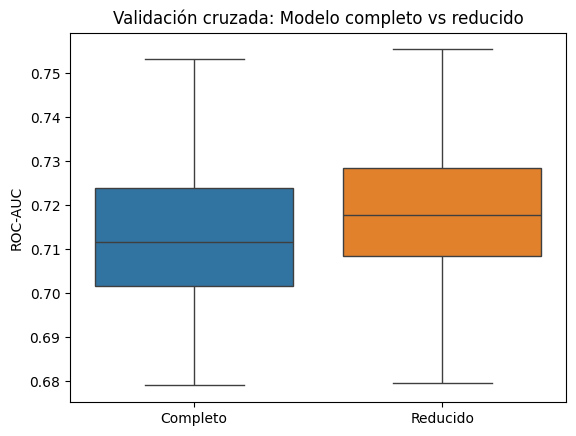

In [97]:
sns.boxplot(data=results)
plt.ylabel("ROC-AUC")
plt.title("Validación cruzada: Modelo completo vs reducido")
plt.show()



* **El sesgo** se interpreta como la media del ROC-AUC obtenido mediante validación cruzada y refleja la capacidad promedio del modelo para discriminar entre clases. **La varianza** se mide como la desviación estándar del ROC-AUC entre particiones y refleja la estabilidad del modelo ante cambios en la muestra de entrenamiento. En este caso, **ambos modelos presentan sesgo similar** y **varianza comparable**, lo que indica que **el modelo reducido mantiene una capacidad predictiva estable sin pérdida de generalización**.

- 1. **Sesgo (MEdia del AUC):** Observando la mediana y la posición central de las cajas,

  Modelo Completo ≈ 0.71–0.72

  Modelo reducido ≈ ligeramente superior (≈ 0.72)

El modelo reducido presenta una capacidad discriminativa similar o ligeramente mejor.

  2. **Varianza (dispersión del AUC)**: Ambos modelos muestran dispersión similar. El reducido parece ligeramente más estable (caja algo mas compacta).

  No hay aumento de varianza al simplificar el modelo.

Por tanto, **el modelo reducido** logra mejor equilibrio entre complejidad y generalización.
